In [19]:
# Imports necessary programs, as well as the dataset to be worked with.
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
cafedata = pd.DataFrame(pd.read_csv('dirty_cafe_sales.csv'))
pd.set_option('display.max_columns', None)

In [20]:
# A preliminary sample of our dirty data to get a taste of what we're looking at. Unknowns, errors, and the like are everywhere here. 
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1703,TXN_8512466,UNKNOWN,5,3.0,15.0,NaN,NaN,2023-02-10
3509,TXN_1503903,Tea,1,1.5,1.5,Cash,Takeaway,2023-03-20
3819,TXN_9405019,Cake,5,3.0,15.0,NaN,NaN,NaN
6785,TXN_9598764,Juice,ERROR,3.0,6.0,Credit Card,In-store,2023-09-06
736,TXN_5763254,Coffee,3,UNKNOWN,6.0,Digital Wallet,Takeaway,2023-09-15
1241,TXN_2923987,UNKNOWN,4,2.0,8.0,Cash,Takeaway,2023-03-28
2026,TXN_5807634,Sandwich,5,4.0,20.0,Digital Wallet,NaN,2023-05-23
4103,TXN_7771526,Juice,1,3.0,3.0,Cash,In-store,2023-04-28
7360,TXN_9321776,Cake,1,3.0,3.0,NaN,UNKNOWN,2023-04-23
5072,TXN_8374101,Salad,5,5.0,25.0,Credit Card,NaN,2023-08-16


In [21]:
# Sorts values by Transaction ID to obtain an estimated date order, and replaces all missing values with np.nan to make later calculations much easier.
cafedata.sort_values(by='Transaction ID', inplace=True)
cafedata.reset_index(drop=True, inplace=True)
cafedata.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

In [22]:
# Establishes a canon price guide according to the website source, then fills accordingly for item price when it can.
price_guide = {
    'Sandwich': 4.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}
for i in range(len(cafedata)):
    if cafedata['Item'].values[i] in price_guide.keys():
        cafedata['Price Per Unit'].values[i] = price_guide[cafedata['Item'].values[i]]

In [23]:
# Sets the numeric values to floats, then uses their dependence on each other to fill in missing values when only one of three values is missing.
cafedata[['Quantity', 'Total Spent', 'Price Per Unit']] = cafedata[['Quantity', 'Total Spent', 'Price Per Unit']].astype(float)
cafedata.fillna({'Quantity': cafedata['Total Spent'] / cafedata['Price Per Unit']}, inplace=True)
cafedata.fillna({'Price Per Unit': cafedata['Total Spent'] / cafedata['Quantity']}, inplace=True)
cafedata.fillna({'Total Spent': cafedata['Quantity'] * cafedata['Price Per Unit']}, inplace=True)

In [24]:
# Fills null dates with the previous transaction's date to attempt to get the values close enough - unfortunately, the Transaction IDs aren't in date order! Then sets the format to datetime.
# cafedata['Transaction Date'] = cafedata['Transaction Date'].ffill()
# cafedata['Transaction Date'] = pd.to_datetime(cafedata['Transaction Date'])
cafedata['Transaction Date'] = pd.to_datetime(
    cafedata['Transaction Date'], errors='coerce'
)
cafedata = cafedata.sort_values('Transaction Date')
cafedata['Transaction Date'] = cafedata['Transaction Date'].ffill()

In [25]:
# For uniquely priced items, retroactively sets the item value from the price per item.
for i in range(len(cafedata)):
    if cafedata['Price Per Unit'].values[i] in [1.0, 1.5, 2.0, 5.0]:
        cafedata['Item'].values[i] = list(price_guide.keys())[list(price_guide.values()).index(cafedata['Price Per Unit'].values[i])]

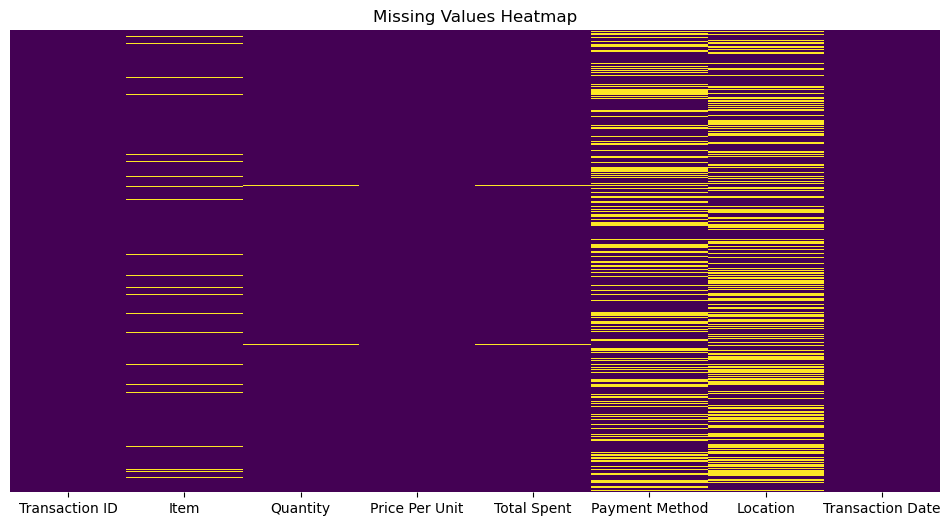

In [26]:
# Visualize missingness
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [27]:
# Investigating the remaining missing Quantity data, we can reason with a few remaining missing data points and impute the rest.
cafedata[cafedata['Price Per Unit'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2932,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
7108,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
206,TXN_1208561,NaN,NaN,NaN,20.0,Credit Card,NaN,2023-08-19
7279,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
87,TXN_1082717,NaN,NaN,NaN,9.0,Digital Wallet,In-store,2023-12-13
9601,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14


In [28]:
# Notably, one entry for Total Spent is 25.0, which means it must be 5 salads purchased. (5 items max, only salad is $5)
# Additionally, Total Spent at 9.0 must be three $3 items thanks to the 5 quantity maximum, though we don't know the specific item.
cafedata['Price Per Unit'].values[87] = 3.0
cafedata['Quantity'].values[87] = 3.0
cafedata['Price Per Unit'].values[7108] = 5.0
cafedata['Quantity'].values[7108] = 5.0
cafedata['Item'].values[7108] = 'Salad'

In [29]:
# At this point, we are out of values to fill in with other information. 
# A key decision: impute values and risk getting false data, remove missing values and lose a lot of data, or mark as unknown?
# For payment method and location, we will keep null, because they are not as essential for computing total revenue. (Can use rate metrics to infer later on)
# For numeric data, it's time to impute! Out of 10,000 transactions, only 23 are missing Total Spent data, which means inferrals should not overall impact data analysis.
# For this imputation, we will use K-Nearest Neighbors, and thus will have to prep our categorical variables as dummies.
cafedata['Year'] = cafedata['Transaction Date'].dt.year
cafedata['Month'] = cafedata['Transaction Date'].dt.month
cafedata['Weekday'] = cafedata['Transaction Date'].dt.weekday
cafedata['Day'] = cafedata['Transaction Date'].dt.day
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Item']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Payment Method']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Location']).astype(int)], axis=1)

In [30]:
# KNN Imputation for Numerical Features
from sklearn.impute import KNNImputer

# Select numerical columns (after removing near-zero variance features)
num_cols = cafedata.select_dtypes(include=[np.number]).columns

# Initialize the imputer
# KNNImpute, unfortunately, uses a mean among k neighbors rather than a mode, so for distinct variables we'll have to use the single nearest neighbor.
imputer = KNNImputer(n_neighbors=1)
cafedata[num_cols] = imputer.fit_transform(cafedata[num_cols])

print("Missing values after KNN imputation (numerical):")
print(cafedata[num_cols].isnull().sum())

Missing values after KNN imputation (numerical):
Quantity          0
Price Per Unit    0
Total Spent       0
Year              0
Month             0
Weekday           0
Day               0
Cake              0
Coffee            0
Cookie            0
Juice             0
Salad             0
Sandwich          0
Smoothie          0
Tea               0
Cash              0
Credit Card       0
Digital Wallet    0
In-store          0
Takeaway          0
dtype: int64


In [13]:
# Lastly, we're missing some Item values when the Price Per Unit is 3.0 or 4.0 due to multiple items having the same price. 
# We'll use an XGBoost classifier to set each instance to one item or the other.
# You're going to need to install xgboost if you don't already have it.
!pip install xgboost

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.8/101.7 MB 1.4 MB/s eta 0:01:13
      --------------------------------------- 1.3/101.7 MB 1.7 MB/s eta 0:00:59
      --------------------------------------- 2.1/101.7 MB 2.3 MB/s eta 0:00:45
     - -------------------------------------- 3.7/101.7 MB 3.3 MB/s eta 0:00:31
     -- ------------------------------------- 5.2/101.7 MB 4.0 MB/s eta 0:00:25
     --- ------------------------------------ 7.9/101.7 MB 5.3 MB/s eta 0:00:18
     ---- ---------------------------------- 10.7/101.7 MB 6.3 MB/s eta 0:00:15
     ---- ---------------------------------- 11.8/101.7 MB 6.4 MB/s eta 0:00:15
     --


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# Cake vs Juice
from xgboost import XGBRegressor

X_train, X_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 3.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 3.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']]
y_train, y_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 3.0))]['Cake'], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 3.0))]['Cake']
xgr = XGBRegressor()
xgr.fit(X_train, y_train)
y_pred3 = xgr.predict(X_test)
X_test['Item'] = np.where(y_pred3 >= 0.5, 'Cake', 'Juice')
cafedata['Item'] = cafedata['Item'].fillna(X_test['Item'])

In [32]:
# Sandwich vs Smoothie
from xgboost import XGBRegressor

X_train, X_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 4.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 4.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']]
y_train, y_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 4.0))]['Sandwich'], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 4.0))]['Sandwich']
xgr = XGBRegressor()
xgr.fit(X_train, y_train)
y_pred4 = xgr.predict(X_test)
X_test['Item'] = np.where(y_pred4 >= 0.5, 'Sandwich', 'Smoothie')
cafedata['Item'] = cafedata['Item'].fillna(X_test['Item'])

In [33]:
# Testing to see whether values are filled
cafedata[cafedata['Item'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Weekday,Day,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,Cash,Credit Card,Digital Wallet,In-store,Takeaway
7108,TXN_7376255,NaN,5.0,5.0,25.0,NaN,In-store,2023-05-27,2023.0,5.0,5.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


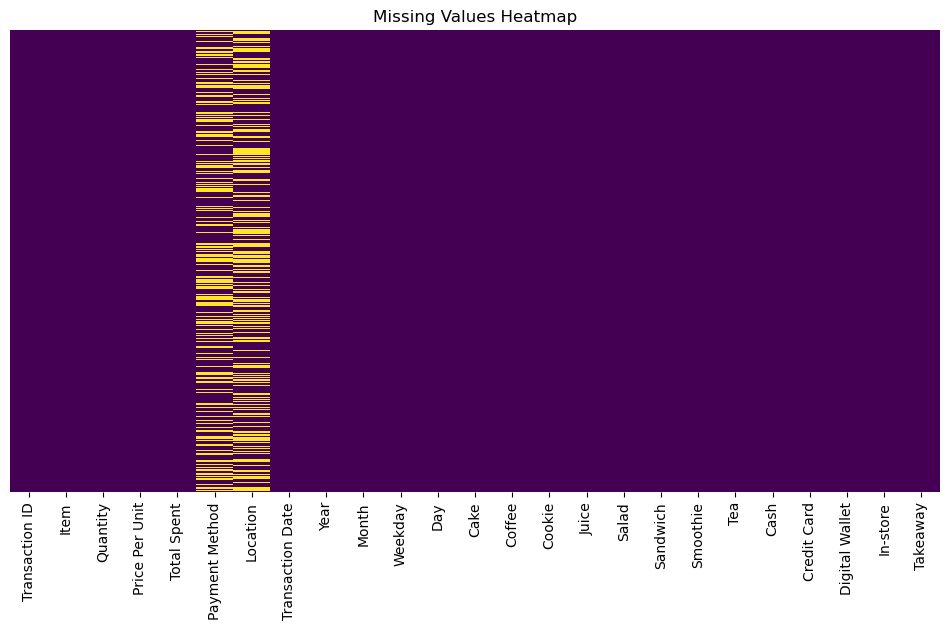

In [34]:
# Another test to see missingness - looks good!
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [35]:
# A final sample to get a look at what our imputed data looks like. We're keeping the dummy variables around in case they're needed for future data analysis!
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Weekday,Day,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,Cash,Credit Card,Digital Wallet,In-store,Takeaway
5934,TXN_6315590,Tea,5.0,1.5,7.5,NaN,In-store,2023-10-04,2023.0,10.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3212,TXN_3849488,Salad,1.0,5.0,5.0,NaN,In-store,2023-03-01,2023.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4759,TXN_5239202,Cake,1.0,3.0,3.0,NaN,NaN,2023-09-14,2023.0,9.0,3.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4015,TXN_4559065,Juice,1.0,3.0,3.0,Cash,In-store,2023-05-03,2023.0,5.0,2.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
147,TXN_1152249,Smoothie,3.0,4.0,12.0,NaN,In-store,2023-05-09,2023.0,5.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2643,TXN_3365018,Juice,5.0,3.0,15.0,Cash,Takeaway,2023-02-06,2023.0,2.0,0.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1491,TXN_2313646,Sandwich,3.0,4.0,12.0,NaN,In-store,2023-08-24,2023.0,8.0,3.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
401,TXN_1392546,Cake,2.0,3.0,6.0,Digital Wallet,In-store,2023-12-06,2023.0,12.0,2.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6082,TXN_6428593,Tea,5.0,1.5,7.5,NaN,NaN,2023-09-06,2023.0,9.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7917,TXN_8103630,Cookie,1.0,1.0,1.0,Digital Wallet,Takeaway,2023-03-08,2023.0,3.0,2.0,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


# Exploratory Data Analysis (EDA)

## Generate summary statistics and descriptive insights

In [36]:
# basic structure
print("Dataset shape:", cafedata.shape)

# Field type & Non-null case
cafedata.info()

Dataset shape: (10000, 25)
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1241 to 9999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9999 non-null   object        
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    6822 non-null   object        
 6   Location          6039 non-null   object        
 7   Transaction Date  10000 non-null  datetime64[ns]
 8   Year              10000 non-null  float64       
 9   Month             10000 non-null  float64       
 10  Weekday           10000 non-null  float64       
 11  Day               10000 non-null  float64       
 12  Cake              10000 non-null  float64       
 13  Coffee            10000 non-null  float64       
 14

In [38]:
# Missing rates in each column
missing_rate = cafedata.isna().mean().sort_values(ascending=False)
missing_rate

Location            0.3961
Payment Method      0.3178
Item                0.0001
Transaction ID      0.0000
Cookie              0.0000
In-store            0.0000
Digital Wallet      0.0000
Credit Card         0.0000
Cash                0.0000
Tea                 0.0000
Smoothie            0.0000
Sandwich            0.0000
Salad               0.0000
Juice               0.0000
Cake                0.0000
Coffee              0.0000
Day                 0.0000
Weekday             0.0000
Month               0.0000
Year                0.0000
Transaction Date    0.0000
Total Spent         0.0000
Price Per Unit      0.0000
Quantity            0.0000
Takeaway            0.0000
dtype: float64

## Descriptive statistics of numerical variables

In [39]:
numeric_cols = ['Total Spent', 'Quantity', 'Price Per Unit']
cafedata[numeric_cols].describe()

,Total Spent,Quantity,Price Per Unit
count,10000.000000,10000.000000,10000.000000
mean,8.930650,3.025700,2.947350
std,6.002059,1.420507,1.279831
min,1.000000,1.000000,1.000000
25%,4.000000,2.000000,2.000000
50%,8.000000,3.000000,3.000000
75%,12.000000,4.000000,4.000000
max,25.000000,5.000000,5.000000


## Categorical variable frequency statistics

In [40]:
categorical_cols = ['Item', 'Location', 'Payment Method']
for col in categorical_cols:
    print(f"\nFrequency of {col}:")
    print(cafedata[col].value_counts())


Frequency of Item:
Item
Juice       1294
Coffee      1291
Salad       1273
Cake        1266
Sandwich    1245
Cookie      1213
Smoothie    1210
Tea         1207
Name: count, dtype: int64

Frequency of Location:
Location
Takeaway    3022
In-store    3017
Name: count, dtype: int64

Frequency of Payment Method:
Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64


In [42]:
total_revenue = cafedata['Total Spent'].sum()
avg_transaction_value = cafedata['Total Spent'].mean()
total_transactions = len(cafedata)
total_revenue, avg_transaction_value, total_transactions

(89306.5, 8.93065, 10000)

Total revenue generated: $89306.5

Average transaction value: $8.93065

Number of transactions: 10000

## Numerical variable distribution (Histogram + KDE)

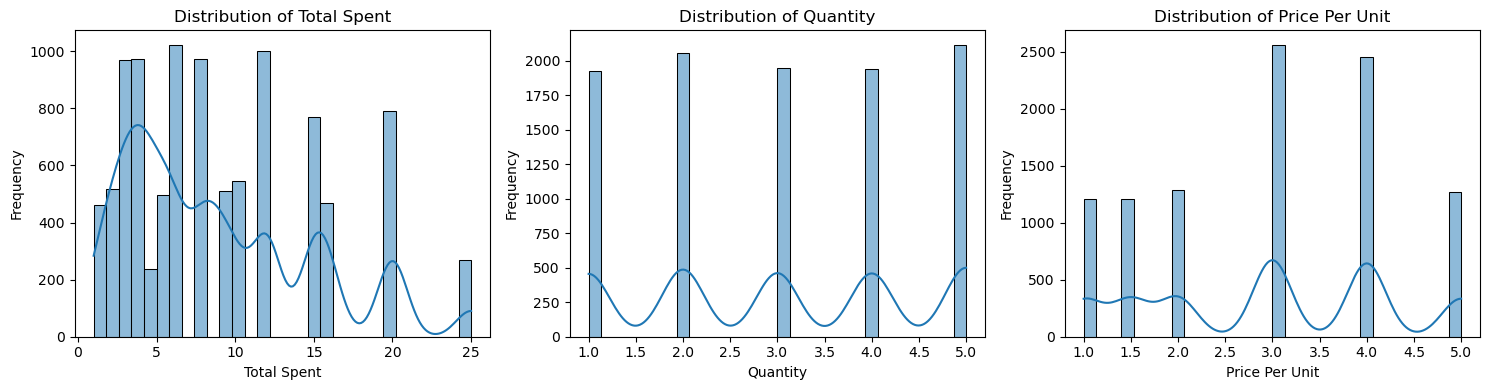

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['Total Spent', 'Quantity', 'Price Per Unit']
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(cafedata[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Boxplot for Outliers

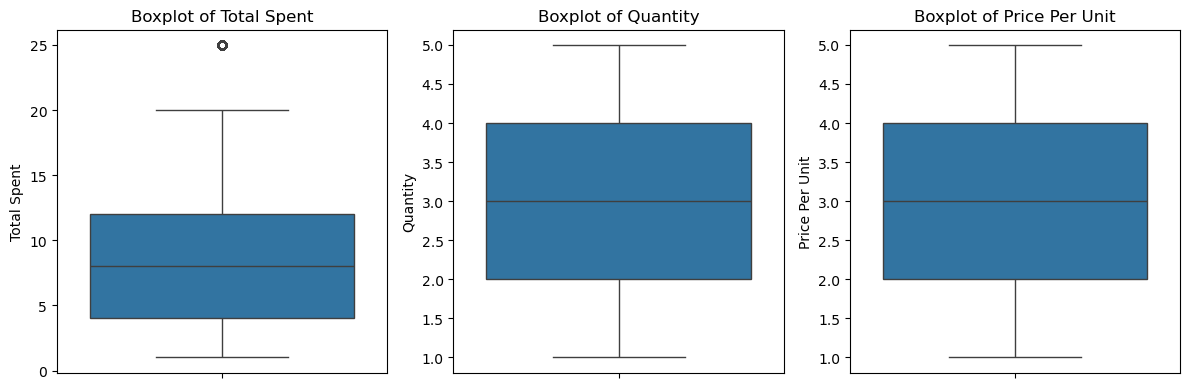

In [44]:
plt.figure(figsize=(12,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=cafedata[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Consumption distribution of different goods (Item × Total Spent)

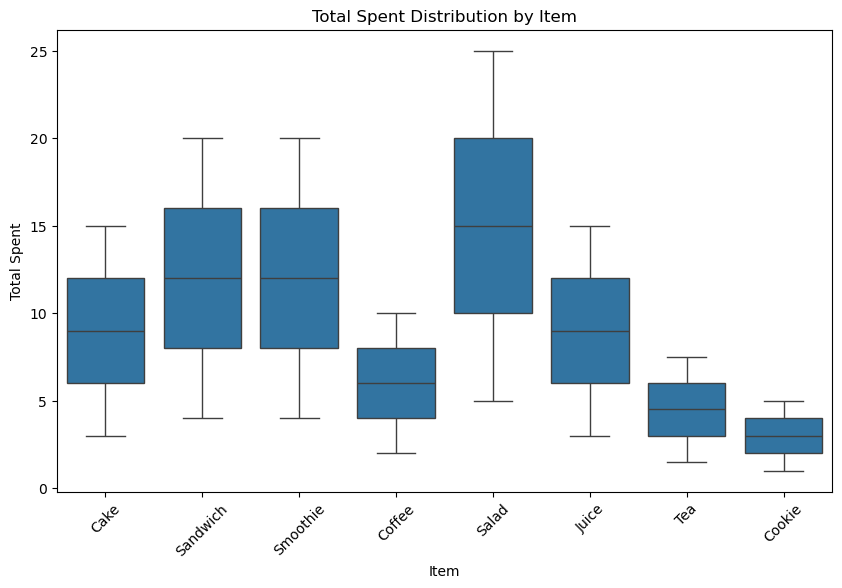

In [45]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=cafedata,
    x='Item',
    y='Total Spent'
)
plt.xticks(rotation=45)
plt.title('Total Spent Distribution by Item')
plt.xlabel('Item')
plt.ylabel('Total Spent')
plt.show()

## Transaction frequency of Top Items

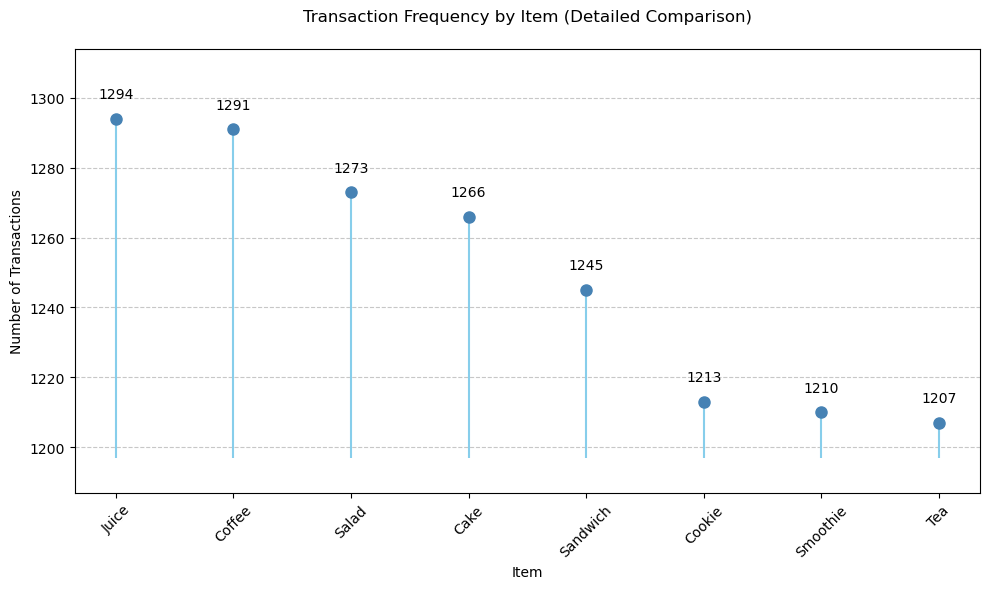

In [49]:
item_counts = cafedata['Item'].value_counts()

plt.figure(figsize=(10, 6))
plt.vlines(x=item_counts.index, ymin=item_counts.min() - 10, ymax=item_counts.values, color='skyblue')
plt.plot(item_counts.index, item_counts.values, "o", markersize=8, color='steelblue')
plt.ylim(item_counts.min() - 20, item_counts.max() + 20)
for i, v in enumerate(item_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.title('Transaction Frequency by Item (Detailed Comparison)', pad=20)
plt.xlabel('Item')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Quantity × Total Spent

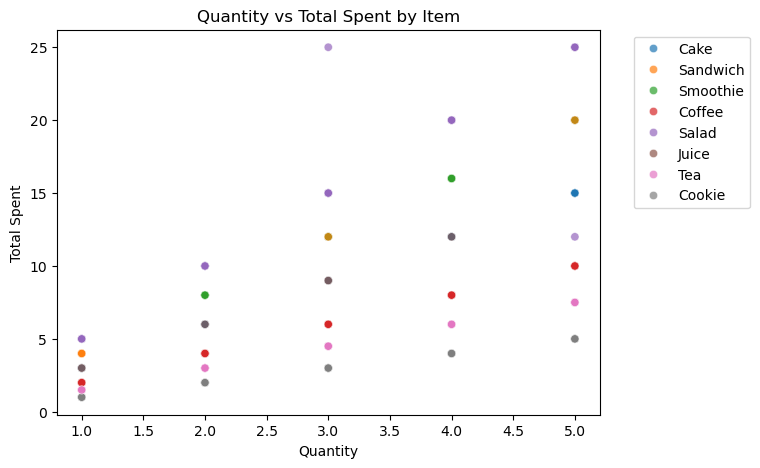

In [52]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=cafedata,
    x='Quantity',
    y='Total Spent',
    hue='Item',
    alpha=0.7
)
plt.title('Quantity vs Total Spent by Item')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Price Per Unit × Total Spent

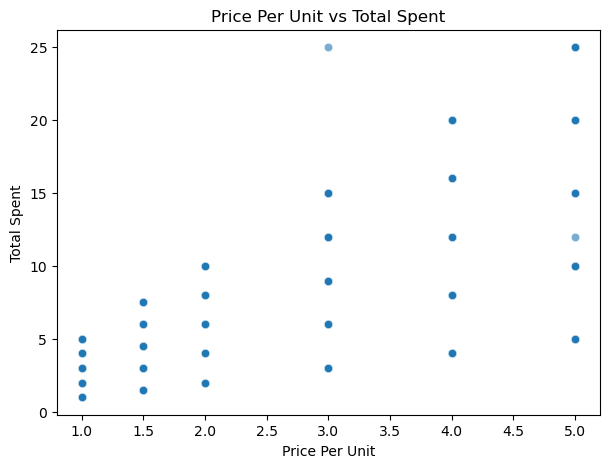

In [53]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=cafedata,
    x='Price Per Unit',
    y='Total Spent',
    alpha=0.6
)
plt.title('Price Per Unit vs Total Spent')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.show()

## Payment Method × Item

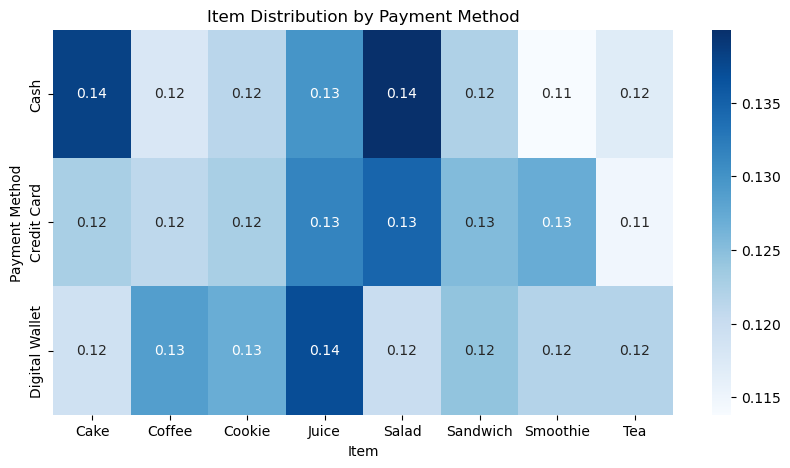

In [63]:
payment_item = pd.crosstab(
    cafedata['Payment Method'],
    cafedata['Item'],
    normalize='index'
)

plt.figure(figsize=(10,5))
sns.heatmap(
    payment_item,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Item Distribution by Payment Method')
plt.xlabel('Item')
plt.ylabel('Payment Method')
plt.show()

## Item × Location
Objective: To discover "certain products are more popular in certain locations".

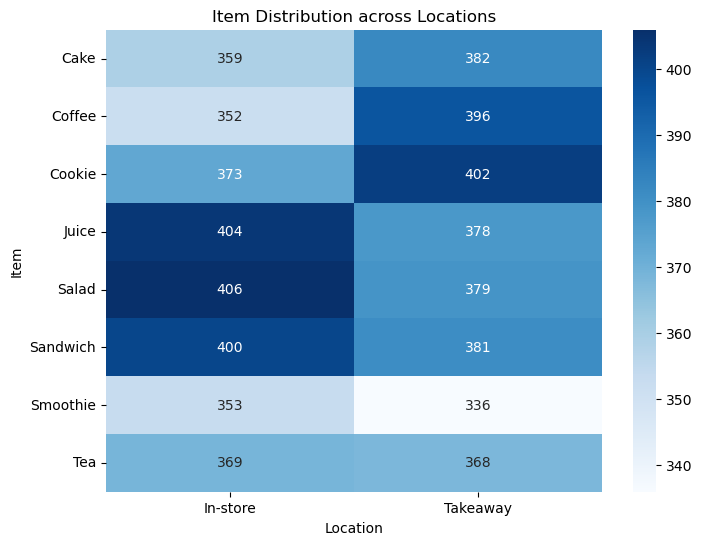

In [62]:
item_location = pd.crosstab(
    cafedata['Item'],
    cafedata['Location']
)

plt.figure(figsize=(8,6))
sns.heatmap(
    item_location,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Item Distribution across Locations')
plt.xlabel('Location')
plt.ylabel('Item')
plt.show()

## Visualize Trends

### Overall trend by "Date"

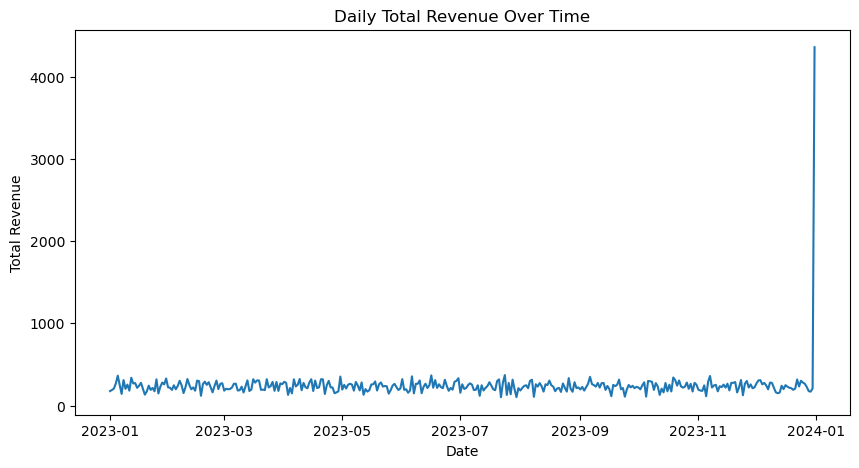

In [65]:
daily_revenue = (
    cafedata
    .groupby('Transaction Date')['Total Spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(daily_revenue['Transaction Date'], daily_revenue['Total Spent'])
plt.title('Daily Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

## Daily transaction trend

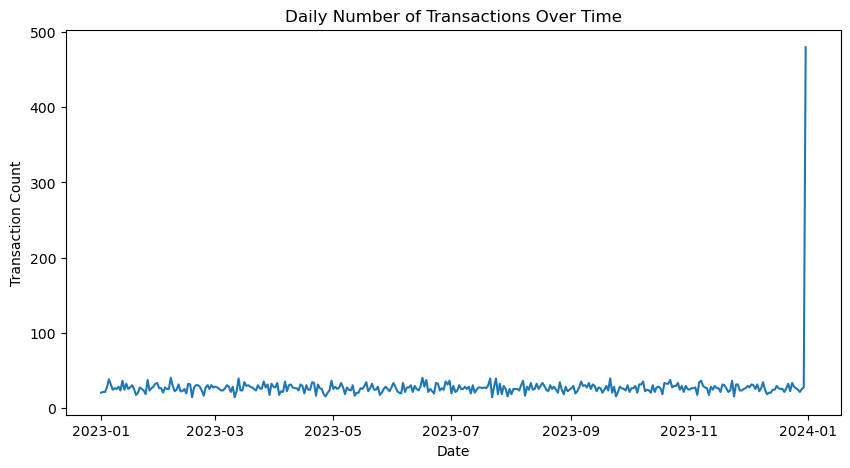

In [66]:
daily_transactions = (
    cafedata
    .groupby('Transaction Date')
    .size()
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(10,5))
plt.plot(
    daily_transactions['Transaction Date'],
    daily_transactions['Transaction Count']
)
plt.title('Daily Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.show()

## Average Transaction Value by Month

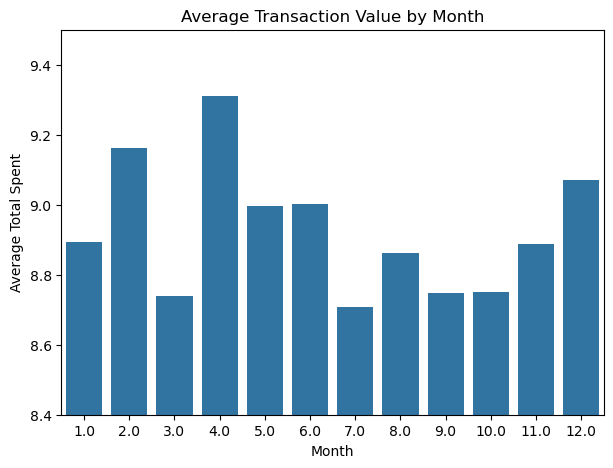

In [72]:
monthly_avg = (
    cafedata
    .groupby('Month')['Total Spent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=monthly_avg,
    x='Month',
    y='Total Spent'
)
plt.ylim(8.4, 9.5)
plt.title('Average Transaction Value by Month')
plt.xlabel('Month')
plt.ylabel('Average Total Spent')
plt.show()

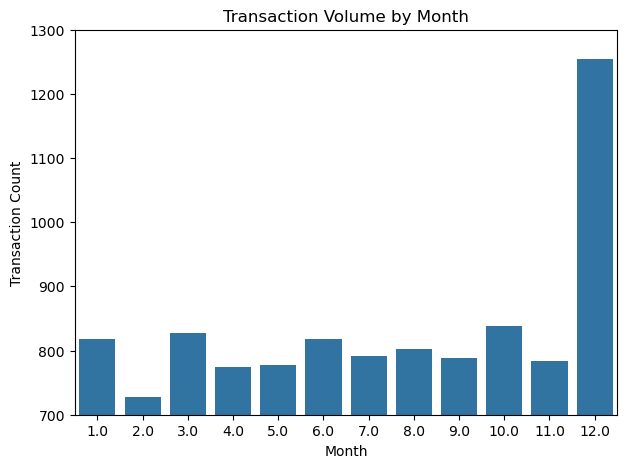

In [75]:
monthly_count = (
    cafedata
    .groupby('Month')
    .size()
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=monthly_count,
    x='Month',
    y='Transaction Count'
)
plt.ylim(700,1300)
plt.title('Transaction Volume by Month')
plt.xlabel('Month')
plt.ylabel('Transaction Count')
plt.show()

## Weekday Model

In [78]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']

cafedata['Weekday_Name'] = cafedata['Transaction Date'].dt.day_name()

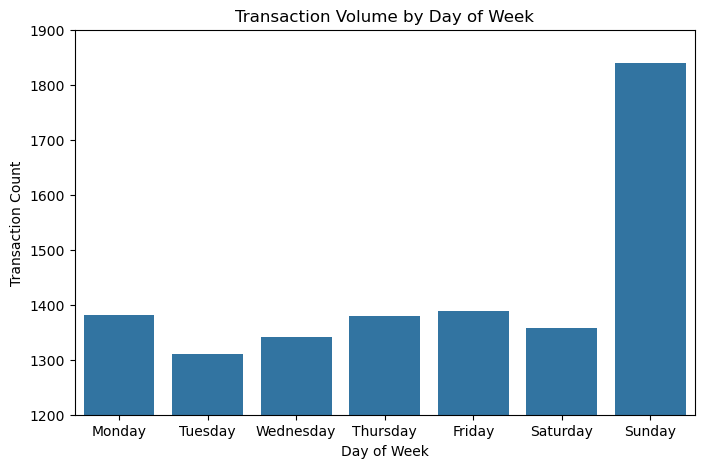

In [81]:
weekday_count = (
    cafedata
    .groupby('Weekday_Name')
    .size()
    .reindex(weekday_order)
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_count,
    x='Weekday_Name',
    y='Transaction Count'
)
plt.ylim(1200, 1900)
plt.title('Transaction Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.show()

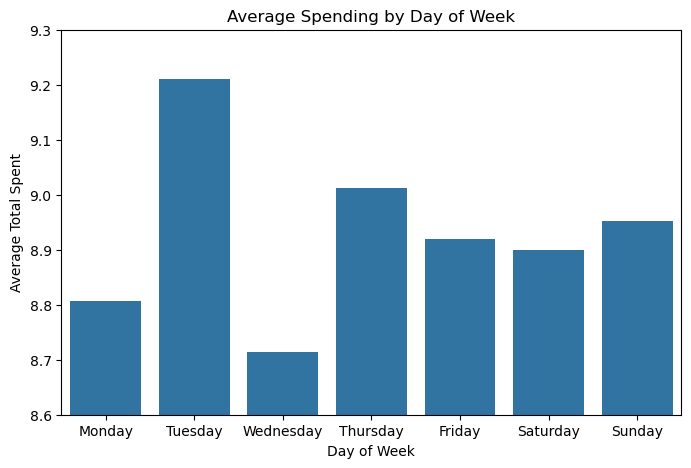

In [85]:
weekday_avg = (
    cafedata
    .groupby('Weekday_Name')['Total Spent']
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_avg,
    x='Weekday_Name',
    y='Total Spent'
)
plt.ylim(8.6,9.3)
plt.title('Average Spending by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Spent')
plt.show()

## Time × Product Trends

Purpose: To see "what sells when".

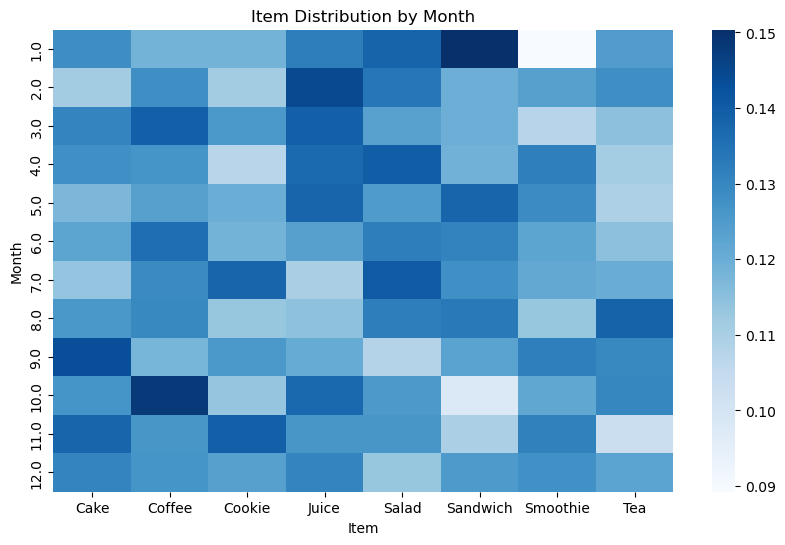

In [86]:
item_month = pd.crosstab(
    cafedata['Month'],
    cafedata['Item'],
    normalize='index'
)

plt.figure(figsize=(10,6))
sns.heatmap(
    item_month,
    cmap='Blues'
)
plt.title('Item Distribution by Month')
plt.xlabel('Item')
plt.ylabel('Month')
plt.show()

## Patterns, Correlations, and Anomalies

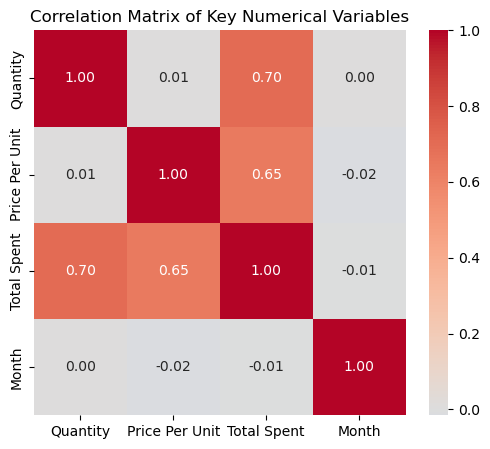

In [88]:
# Correlation
corr_vars = [
    'Quantity',
    'Price Per Unit',
    'Total Spent',
    'Month'
]

corr_matrix = cafedata[corr_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix of Key Numerical Variables')
plt.show()

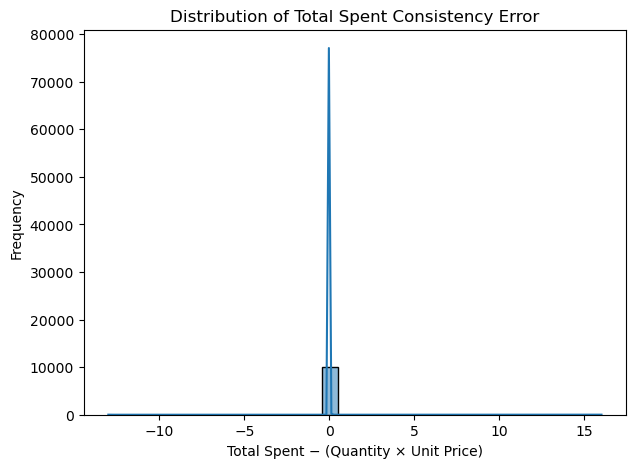

In [91]:
# Error Distribution
cafedata['calc_error'] = (
    cafedata['Total Spent']
    - cafedata['Quantity'] * cafedata['Price Per Unit']
)

plt.figure(figsize=(7,5))
sns.histplot(
    cafedata['calc_error'],
    bins=30,
    kde=True
)
plt.title('Distribution of Total Spent Consistency Error')
plt.xlabel('Total Spent − (Quantity × Unit Price)')
plt.ylabel('Frequency')
plt.show()

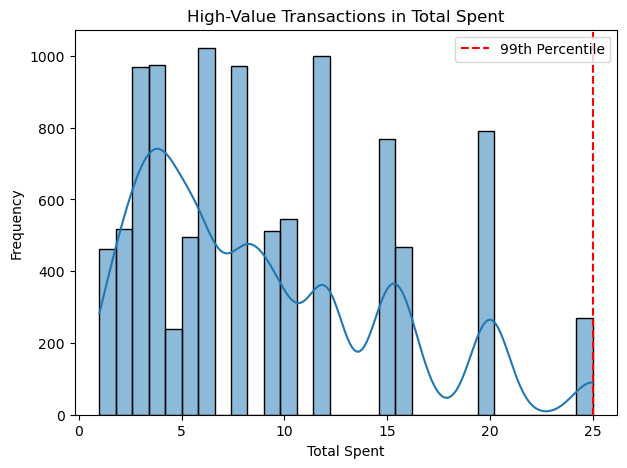

In [90]:
# Outlier
threshold = cafedata['Total Spent'].quantile(0.99)

high_value_tx = cafedata[cafedata['Total Spent'] >= threshold]

plt.figure(figsize=(7,5))
sns.histplot(
    cafedata['Total Spent'],
    bins=30,
    kde=True
)
plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    label='99th Percentile'
)
plt.legend()
plt.title('High-Value Transactions in Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()